## Replication of Ericson (2014)
Paper: Ericson, Keith. "Consumer Inertia and Firm Pricing in the Medicare Part D Prescription Drug Insurance Exchange"

Requires:
  - Data_main.dta
  - Data_subsidyinfo.dta
Produces:
  - CSV tables in Analysis_output/
  - PNG figures in Analysis_output/

Notes:
  - This is a close translation, not a line-by-line byte-identical reproduction.
  - Stata's outreg2/XML and .gph outputs are replaced with CSV and PNG outputs.
  - Some Stata factor-variable conventions are implemented with fixest formulas.
  - Cluster-robust SEs are computed at the firmID level.


### Set-up

In [1]:
# Install reuired packages
install.packages(c("haven", "tidyverse", "ggplot2", "fixest", "modelsummary"))

# Load libraries
suppressPackageStartupMessages({
  library(haven)
  library(tidyverse)    
  library(ggplot2)
  library(fixest)
  library(modelsummary)
})

# Create output directory
dir.create("Analysis_output", showWarnings = FALSE)

Installing packages into 'C:/Users/kater/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'haven' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'haven'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\kater\AppData\Local\R\win-library\4.5\00LOCK\haven\libs\x64\haven.dll to C:\Users\kater\AppData\Local\R\win-library\4.5\haven\libs\x64\haven.dll: Permission denied"
Warning message:
"restored 'haven'"


package 'tidyverse' successfully unpacked and MD5 sums checked
package 'ggplot2' successfully unpacked and MD5 sums checked
package 'fixest' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'fixest'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\kater\AppData\Local\R\win-library\4.5\00LOCK\fixest\libs\x64\fixest.dll to C:\Users\kater\AppData\Local\R\win-library\4.5\fixest\libs\x64\fixest.dll: Permission denied"
Warning message:
"restored 'fixest'"


package 'modelsummary' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\kater\AppData\Local\Temp\RtmpQX1Ti1\downloaded_packages


Warning message:
"package 'tidyverse' was built under R version 4.5.3"
Warning message:
"package 'ggplot2' was built under R version 4.5.3"
Warning message:
"package 'modelsummary' was built under R version 4.5.3"


### Explore the data

In [2]:
main_data <- read_dta("../../data/Data_main.dta")
subsidies <- read_dta("../../data/Data_subsidyinfo.dta")

# Look at dimensions, variables, and first few rows of the data
dim(main_data)
names(main_data)
head(main_data)

dim(subsidies)
names(subsidies)
head(subsidies)

[1] 8382   19

[1] "orgParentCode"       "MAPlan"              "planName"           
 [4] "enrollment"          "enrollmentImpute"    "uniqueID"           
 [7] "year"                "premium"             "deductible"         
[10] "gap"                 "contractId"          "planNumber"         
[13] "btypedetail"         "state"               "PDPregion"          
[16] "LIS"                 "benefit"             "enrollmentLIS"      
[19] "enrollmentLISimpute"

orgParentCode,MAPlan,planName,enrollment,enrollmentImpute,uniqueID,year,premium,deductible,gap,contractId,planNumber,btypedetail,state,PDPregion,LIS,benefit,enrollmentLIS,enrollmentLISimpute
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
Aetna Inc.,1,Aetna Medicare Rx Essentials,494,494,S5810-037,2006,32.78,250,,S5810,37,AE,NY,3,0,B,207,207
AmeriHealth Mercy Health Plan,0,PerformRx Option II,160,160,S5650-003,2007,33.00,0,,S5650,3,BA,SC,9,1,B,48,48
"America's Health Choice Medical Plans, Inc",1,AHC Prescription Drug Plan,778,778,S9086-001,2006,48.44,250,,S9086,1,DS,FL,11,0,B,164,164
Arkansas Blue Cross Blue Shield,1,AR Blue Cross - Medi-Pak Rx Basic (PDP),32062,32062,S5795-003,2010,25.90,200,No Gap Coverage,S5795,3,BA,AR,19,1,B,NA,NA
"BCBS MN, MT, NE, ND, WY, Wellmark IA and SD",1,Blue MedicareRx - Option 2,7637,7637,S2893-002,2006,37.15,0,,S2893,2,EA,VT,2,0,E,317,317
BCBS OF AL & BCBS OF TN,1,Blue Rx Option I,6035,6035,S1030-001,2007,35.50,0,,S1030,1,BA,AL,12,0,B,210,210


[1] 34  6

[1] "PDPregion" "s2006"     "s2007"     "s2008"     "s2009"     "s2010"

PDPregion,s2006,s2007,s2008,s2009,s2010
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,36.09,30.72,30.64,28.12,26.96
2,30.27,27.35,29.17,31.74,34.57
3,29.83,24.45,24.18,27.71,33.32
4,31.37,28.12,31.23,30.99,35.01
5,33.46,29.65,30.78,30.85,33.71
6,32.59,28.45,26.59,29.23,32.09


### Table 1: Descriptive Statistics of Medicare Part D Plans

1. Define the plan cohorts based on their year of introduction
2. Evaluate the mean monthly premium and mean deductible for each cohort
3. Find the fraction of benefits of "Enhanced" type
4. Find the fraction of plans offered by firms already offering a plan in each cohort:
    * in the US
    * in the same state
5. Find the number of unique firms in each cohort
6. Find the number of plans in each cohort

In [3]:
# Define plan cohorts using each plan's first observed year
plan_intro <- main_data %>%
  group_by(uniqueID) %>%
  arrange(year, .by_group = TRUE) %>%
  slice(1) %>%
  ungroup() %>%
  transmute(
    uniqueID,
    intro_year = year,
    orgParentCode,
    state,
    premium,
    deductible,
    btypedetail
  )

# First year each firm appears in the US market
firm_first_year_us <- plan_intro %>%
  group_by(orgParentCode) %>%
  summarise(firm_first_year_us = min(intro_year), .groups = "drop")

# First year each firm appears in each state market
firm_first_year_state <- plan_intro %>%
  group_by(orgParentCode, state) %>%
  summarise(firm_first_year_state = min(intro_year), .groups = "drop")

# Table 1 statistics by plan cohort (intro year)
table1 <- plan_intro %>%
  left_join(firm_first_year_us, by = "orgParentCode") %>%
  left_join(firm_first_year_state, by = c("orgParentCode", "state")) %>%
  mutate(
    EA_plan = btypedetail == "EA",
    US_existing_firm_plan = firm_first_year_us < intro_year,
    State_existing_firm_plan = firm_first_year_state < intro_year
  ) %>%
  group_by(intro_year) %>%
  summarise(
    mean_monthly_prem = mean(premium, na.rm = TRUE),
    sd_monthly_prem = sd(premium, na.rm = TRUE),
    mean_deductible = mean(deductible, na.rm = TRUE),
    sd_deductible = sd(deductible, na.rm = TRUE),
    unique_firms_number = n_distinct(orgParentCode),
    unique_plans_number = n_distinct(uniqueID),
    EA_fraction = mean(EA_plan, na.rm = TRUE),
    US_existing_firms_fraction = mean(US_existing_firm_plan, na.rm = TRUE),
    State_existing_firms_fraction = mean(State_existing_firm_plan, na.rm = TRUE),
    .groups = "drop"
  )

table1

intro_year,mean_monthly_prem,sd_monthly_prem,mean_deductible,sd_deductible,unique_firms_number,unique_plans_number,EA_fraction,US_existing_firms_fraction,State_existing_firms_fraction
<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<int>,<dbl>,<dbl>,<dbl>
2006,37.43103,12.858465,92.24983,115.7949,51,1429,0.42547236,0.0000000,0.0000000
2007,40.30745,17.146712,114.10334,127.7365,38,658,0.43161094,0.7613982,0.5288754
2008,35.96188,19.571768,146.28713,124.9072,16,202,0.58415842,0.9752475,0.9108911
2009,30.26765,5.335895,253.42647,101.8691,5,68,0.02941176,1.0000000,0.6764706
2010,32.71308,9.222021,118.03738,138.7440,6,107,0.69158879,0.9719626,0.8598131


In [4]:
# Install formatting packages if missing
needed_pkgs <- c("gt", "scales", "webshot2")
missing_pkgs <- needed_pkgs[!vapply(needed_pkgs, requireNamespace, logical(1), quietly = TRUE)]
if (length(missing_pkgs) > 0) {
  install.packages(missing_pkgs)
}

# Format Table 1 to match paper-style layout
suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(gt)
  library(scales)
})

# Build display strings (means with SD on a second line)
table1_display <- table1 %>%
  transmute(
    cohort = as.character(intro_year),
    `Mean monthly premium` = sprintf("$%d<br>(%d)", round(mean_monthly_prem), round(sd_monthly_prem)),
    `Mean deductible` = sprintf("$%d<br>(%d)", round(mean_deductible), round(sd_deductible)),
    `Fraction enhanced benefit` = sprintf("%.2f", EA_fraction),
    `...in the United States` = sprintf("%.2f", US_existing_firms_fraction),
    `...in the same state` = sprintf("%.2f", State_existing_firms_fraction),
    `Number of unique firms` = comma(unique_firms_number),
    `Number of plans` = comma(unique_plans_number)
  ) %>%
  pivot_longer(-cohort, names_to = "row_label", values_to = "value") %>%
  mutate(
    row_order = factor(
      row_label,
      levels = c(
        "Mean monthly premium",
        "Mean deductible",
        "Fraction enhanced benefit",
        "...in the United States",
        "...in the same state",
        "Number of unique firms",
        "Number of plans"
      )
    ),
    row_label = case_when(
      row_label == "Fraction enhanced benefit" ~ "Fraction enhanced benefit",
      TRUE ~ row_label
    )
  ) %>%
  arrange(row_order) %>%
  select(-row_order) %>%
  pivot_wider(names_from = cohort, values_from = value)

# Insert group-label row
label_row <- tibble(
  row_label = "Fraction of plans offered by firms already offering a plan . . .",
  `2006` = "",
  `2007` = "",
  `2008` = "",
  `2009` = "",
  `2010` = ""
)

table1_display <- bind_rows(
  table1_display %>% slice(1:3),
  label_row,
  table1_display %>% slice(4:n())
)

cohort_cols <- setdiff(names(table1_display), "row_label")

gt_tbl <- table1_display %>%
  gt(rowname_col = "row_label") %>%
  tab_header(
    title = md("**TABLE 1-DESCRIPTIVE STATISTICS OF MEDICARE PART D PLANS**")
  ) %>%
  tab_spanner(
    label = "Cohort (Year of plan introduction)",
    columns = all_of(cohort_cols)
  ) %>%
  fmt_markdown(columns = all_of(cohort_cols)) %>%
  fmt_markdown(columns = stub()) %>%
  cols_align(align = "center", columns = all_of(cohort_cols)) %>%
  tab_style(
    style = cell_text(weight = "bold"),
    locations = cells_title(groups = "title")
  ) %>%
  tab_options(
    table.font.size = px(22),
    heading.align = "center",
    column_labels.font.weight = "normal",
    row.striping.background_color = "white",
    table.border.top.color = "black",
    table.border.bottom.color = "black",
    heading.border.bottom.color = "black",
    table.width = px(1100)
  )

gt_tbl

# Save output every time this cell runs
dir.create("../../Analysis_output", showWarnings = FALSE, recursive = TRUE)
png_path <- "../../Analysis_output/Table1_descriptive_stats.png"
html_path <- "../../Analysis_output/Table1_descriptive_stats.html"

tryCatch(
  {
    # Large viewport prevents right-edge truncation in PNG exports
    gtsave(
      gt_tbl,
      png_path,
      vwidth = 2400,
      vheight = 1600,
      zoom = 2,
      expand = 20
    )
    message("Saved PNG: ", png_path)
  },
  error = function(e) {
    message("PNG save failed: ", e$message)
    gtsave(gt_tbl, html_path)
    message("Saved HTML instead: ", html_path)
  }
)

Warning message:
"package 'gt' was built under R version 4.5.3"


<div id="ctipxjkicg" style="padding-left:0px;padding-right:0px;padding-top:10px;padding-bottom:10px;overflow-x:auto;overflow-y:auto;width:auto;height:auto;">
  <style>#ctipxjkicg table {
  font-family: system-ui, 'Segoe UI', Roboto, Helvetica, Arial, sans-serif, 'Apple Color Emoji', 'Segoe UI Emoji', 'Segoe UI Symbol', 'Noto Color Emoji';
  -webkit-font-smoothing: antialiased;
  -moz-osx-font-smoothing: grayscale;
}

#ctipxjkicg thead, #ctipxjkicg tbody, #ctipxjkicg tfoot, #ctipxjkicg tr, #ctipxjkicg td, #ctipxjkicg th {
  border-style: none;
}

#ctipxjkicg p {
  margin: 0;
  padding: 0;
}

#ctipxjkicg .gt_table {
  display: table;
  border-collapse: collapse;
  line-height: normal;
  margin-left: auto;
  margin-right: auto;
  color: #333333;
  font-size: 22px;
  font-weight: normal;
  font-style: normal;
  background-color: #FFFFFF;
  width: 1100px;
  border-top-style: solid;
  border-top-width: 2px;
  border-top-color: #000000;
  border-right-style: none;
  border-right-width: 2px;
 

file:///C:/Users/kater/AppData/Local/Temp/RtmpQX1Ti1/file135447674e0e.html screenshot completed

Saved PNG: ../../Analysis_output/Table1_descriptive_stats.png



### Figure 3: The Effect of 2006 Benchmark Status on 2006 Enrollment

This figure plots the running variable of the RD analysis, evaluated as the difference between the monthly premium and the LIS subsidy in 2006 against the logarithm of the enrollement share for 2006.

In this graph we basically have 3 types of plots:
* 2006 premiums relative to the LIS subsidy amount against 2006 log enrollment share (dots are local averages with a bin size of $0.50.)
* predicted enrollment, controlling for premiums relative to the benchmark in a linear specification (dashed lines are predictions from local linear regressions with bandwidth of $4)
* predicted enrollment, controlling for premiums relative to the benchmark in a quartic polynomial specification (solid lines are predictions from regressions with a quartic polynomial with a bandwidth of $10)

Define the variable “relative premiums” to be a plan’s premiums minus that state’s benchmark level.



In [5]:
# We want to reshape the whole subsidy dataset to have one row per plan-year, 
# so we can easily merge it with the main data later on if needed.

subsidies_long <- subsidies %>%
  pivot_longer(
    cols = starts_with("s"),
    names_to = "year",
    names_prefix = "s",
    values_to = "subsidy_amount"
  ) %>%
  mutate(year = as.integer(year))

  head(subsidies_long)


PDPregion,year,subsidy_amount
<dbl>,<int>,<dbl>
1,2006,36.09
1,2007,30.72
1,2008,30.64
1,2009,28.12
1,2010,26.96
2,2006,30.27


In [6]:
# Now we can merge the subsidy data with the main data to get subsidy information for each plan-year.

main_data <- main_data %>%
  left_join(subsidies_long, by = c("PDPregion" = "PDPregion", "year" = "year"))


head(main_data)

orgParentCode,MAPlan,planName,enrollment,enrollmentImpute,uniqueID,year,premium,deductible,gap,contractId,planNumber,btypedetail,state,PDPregion,LIS,benefit,enrollmentLIS,enrollmentLISimpute,subsidy_amount
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
Aetna Inc.,1,Aetna Medicare Rx Essentials,494,494,S5810-037,2006,32.78,250,,S5810,37,AE,NY,3,0,B,207,207,29.83
AmeriHealth Mercy Health Plan,0,PerformRx Option II,160,160,S5650-003,2007,33.00,0,,S5650,3,BA,SC,9,1,B,48,48,31.41
"America's Health Choice Medical Plans, Inc",1,AHC Prescription Drug Plan,778,778,S9086-001,2006,48.44,250,,S9086,1,DS,FL,11,0,B,164,164,29.07
Arkansas Blue Cross Blue Shield,1,AR Blue Cross - Medi-Pak Rx Basic (PDP),32062,32062,S5795-003,2010,25.90,200,No Gap Coverage,S5795,3,BA,AR,19,1,B,NA,NA,28.48
"BCBS MN, MT, NE, ND, WY, Wellmark IA and SD",1,Blue MedicareRx - Option 2,7637,7637,S2893-002,2006,37.15,0,,S2893,2,EA,VT,2,0,E,317,317,30.27
BCBS OF AL & BCBS OF TN,1,Blue Rx Option I,6035,6035,S1030-001,2007,35.50,0,,S1030,1,BA,AL,12,0,B,210,210,29.60


In [7]:
# We will start by subsetting to 2006 data, 
# and then we can create the running variable (distance to cutoff) 
# and treatment indicator (whether above or below cutoff) in the next steps.

relative_premium_2006 <- main_data %>%
  filter(year == 2006) %>%
  mutate(
    relative_premium = premium - subsidy_amount,
    treated = relative_premium > 0
  )

head(relative_premium_2006)

orgParentCode,MAPlan,planName,enrollment,enrollmentImpute,uniqueID,year,premium,deductible,gap,⋯,btypedetail,state,PDPregion,LIS,benefit,enrollmentLIS,enrollmentLISimpute,subsidy_amount,relative_premium,treated
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,⋯,<chr>,<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>
Aetna Inc.,1,Aetna Medicare Rx Essentials,494,494,S5810-037,2006,32.78,250,,⋯,AE,NY,3,0,B,207,207,29.83,2.95,TRUE
"America's Health Choice Medical Plans, Inc",1,AHC Prescription Drug Plan,778,778,S9086-001,2006,48.44,250,,⋯,DS,FL,11,0,B,164,164,29.07,19.37,TRUE
"BCBS MN, MT, NE, ND, WY, Wellmark IA and SD",1,Blue MedicareRx - Option 2,7637,7637,S2893-002,2006,37.15,0,,⋯,EA,VT,2,0,E,317,317,30.27,6.88,TRUE
Blue Cross Blue Shield of Kansas,0,Blue MedicareRx Value,9689,9689,S5726-013,2006,21.09,250,,⋯,AE,KS,24,1,B,4437,4437,33.44,-12.35,FALSE
Blue Cross and Blue Shield of North Carolina,1,BCBSNC Plus Plan,43854,43854,S5540-004,2006,59.60,0,G,⋯,EA,NC,8,0,E,2381,2381,36.30,23.30,TRUE
CIGNA,1,CIGNATURE Rx Complete Plan,1427,1427,S5617-192,2006,47.88,0,G,⋯,EA,TX,22,0,E,345,345,31.68,16.20,TRUE


In [8]:
# Now we want tpo break the running variable into bins to create the binned scatterplot.
# We want to break it in bins of $0.50 and then evaluate the average enrollment share within each bin.

# Create the enrollment share variable
relative_premium_2006 <- relative_premium_2006 %>%
  group_by(PDPregion) %>%
  mutate(enrollment_share = enrollment / sum(enrollment, na.rm = TRUE)) %>%
  ungroup() %>%
  mutate(
    premium_bin = cut(relative_premium, breaks = seq(-10, 10, by = 0.5), include.lowest = TRUE)
  ) %>%
  group_by(premium_bin) %>%
  summarize(avg_enrollment_share = mean(enrollment_share, na.rm = TRUE)) %>%
  mutate(log_avg_enrollment_share = log(avg_enrollment_share + 1e-6)) # Add small constant to avoid log(0)

relative_premium_2006

premium_bin,avg_enrollment_share,log_avg_enrollment_share
<fct>,<dbl>,<dbl>
"[-10,-9.5]",0.030482142,-3.490581
"(-9.5,-9]",0.021380617,-3.845224
"(-9,-8.5]",0.056796114,-2.868270
"(-8.5,-8]",0.057429478,-2.857180
"(-8,-7.5]",0.051516534,-2.965833
"(-7.5,-7]",0.072539529,-2.623610
"(-7,-6.5]",0.061515388,-2.788452
"(-6.5,-6]",0.069828802,-2.661694
"(-6,-5.5]",0.070158898,-2.656978


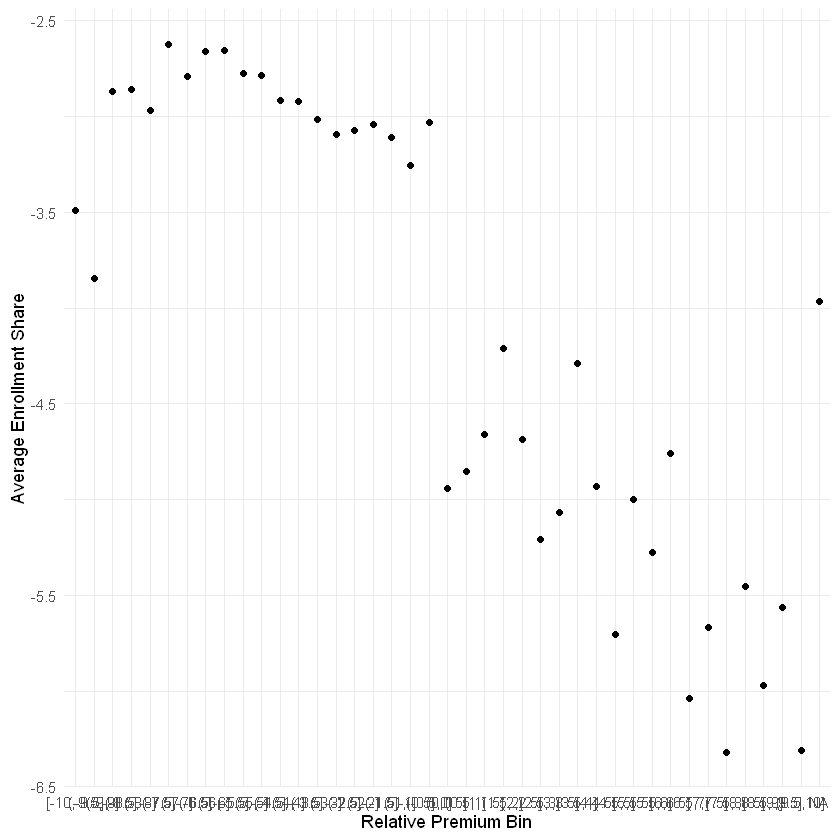

In [9]:
# Let's do a scatter-plot of the binned averages to visualize the relationship between relative premium and enrollment share.
library(ggplot2)

ggplot(relative_premium_2006, aes(x = premium_bin, y = log_avg_enrollment_share)) +
  geom_point() +
  labs(x = "Relative Premium Bin", y = "Average Enrollment Share") +
  theme_minimal()